# 📱 NHIS Project 4
## Feature Extraction & Price Prediction for Mobile Phones

---

> **Author :** Neha Chhapariya  
> **Programme :** NHIS Internship Programme  
> **Dataset :** Flipkart Mobile Phones  
> **Focus :** EDA + Feature Engineering + Price Prediction Readiness  

---

| 📌 Field | 📋 Detail |
|:---|:---|
| **Dataset** | Flipkart Mobile Phones |
| **Records** | 541 mobile phones |
| **Project Focus** | EDA · Feature Engineering · Price Prediction Readiness |
| **Visual Theme** | Deep Purple · Crimson · Amber |
| **Notebook Style** | Inline visuals + interpretation card after every plot |

---

> 📝 *Each visual renders inline and is followed by a styled interpretation card.*


In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120


## 📦 Step 1 — Import Libraries & Configuration

In [2]:
# Step 1 — Import Libraries & Configuration

# Core · Visualisation · ML · Display

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('✅ All libraries imported successfully.')
print(f'   pandas  {pd.__version__}  |  numpy  {np.__version__}')
print(f'   matplotlib  {matplotlib.__version__}  |  seaborn  {sns.__version__}')


✅ All libraries imported successfully.
   pandas  3.0.1  |  numpy  2.4.3
   matplotlib  3.10.8  |  seaborn  0.13.2


## 🎨 Step 1b — Colour Palette & Visualisation Helpers

In [3]:
# Step 1b — Colour Palette & Visualisation Helpers

# Deep Purple / Crimson Theme — Neha Chhapariya

# ── Primary Colour Palette ──────────────────────────────────────
BG     = "#1A0A1E"   # Very dark purple — dominant background
DARK   = "#2D1040"   # Dark purple — panel backgrounds
ACCENT = "#C0392B"   # Crimson red — primary accent
ACCT_L = "#E74C3C"   # Light crimson — highlights
GOLD   = "#F39C12"   # Amber — key callouts
GOLD_L = "#F5B041"   # Light amber — labels
SLATE  = "#3D1155"   # Deep purple — card backgrounds
SLATE_L= "#5E2680"   # Lighter purple
WHITE  = "#FFFFFF"
OFF_W  = "#F5F0FF"   # Off-white (lavender tint) — body text
MUTED  = "#A98FD0"   # Muted lavender — secondary text
RED    = "#E74C3C"   # Strong correlation
GREEN  = "#2ECC71"   # Positive indicator
BLUE   = "#8E44AD"   # Budget tier (purple)
PURPLE = "#6C3483"   # Premium tier (deep violet)
ORANGE = "#D35400"   # Upper mid tier

# ── Tier & Variant Palettes ─────────────────────────────────────
TIER_COLORS = {"Budget": BLUE, "Mid-Range": ACCENT, "Upper Mid": ORANGE, "Premium": PURPLE}
RAM_COLORS  = ["#4A0E5C", "#7D1FA0", "#A93279", "#C0392B", "#E74C3C"]
MEM_COLORS  = ["#6C3483", "#922B21", "#D35400", "#1A5276"]

def style_ax(ax, bg=DARK, gc="#FFFFFF22", sc=ACCENT):
    ax.set_facecolor(bg)
    ax.tick_params(colors=OFF_W, labelsize=10)
    ax.xaxis.label.set_color(OFF_W)
    ax.yaxis.label.set_color(OFF_W)
    ax.title.set_color(WHITE)
    for spine in ax.spines.values():
        spine.set_edgecolor(sc)
        spine.set_linewidth(0.8)
    ax.grid(True, color=gc, linewidth=0.5, linestyle='--')
    return ax

def add_bar_labels(ax, fmt='₹{:,.0f}', color=GOLD_L, fontsize=10):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+max(h*0.01, 200),
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, fontweight='bold', color=color)

def add_hbar_labels(ax, fmt='{:.3f}', color=GOLD_L, fontsize=9):
    for bar in ax.patches:
        w = bar.get_width()
        if abs(w) > 0.001:
            ax.text(w+0.005, bar.get_y()+bar.get_height()/2,
                    fmt.format(w), va='center', fontsize=fontsize,
                    fontweight='bold', color=color)

print('✅ Colour palette & helper functions configured.')
print(f'   Palette  : Deep Purple · Crimson · Amber (Neha Theme)')
print(f'   Helpers  : style_ax  |  add_bar_labels  |  add_hbar_labels')


✅ Colour palette & helper functions configured.
   Palette  : Deep Purple · Crimson · Amber (Neha Theme)
   Helpers  : style_ax  |  add_bar_labels  |  add_hbar_labels


## 📂 Step 2 — Load the Flipkart Dataset

In [4]:
# Step 2 — Load the Flipkart Dataset

# Source: Processed_Flipdata.csv  |  541 Records · 11 Features

df = pd.read_csv('Processed_Flipdata.csv', index_col=0)

print(f'✅ Dataset loaded successfully!')
print(f'   Shape   : {df.shape[0]} rows  ×  {df.shape[1]} columns')
print(f'   Memory  : {df.memory_usage(deep=True).sum()/1024:.1f} KB')
print()
print(df.head(5))


✅ Dataset loaded successfully!
   Shape   : 541 rows  ×  11 columns
   Memory  : 210.6 KB

             Model        Colour  Memory  RAM  Battery_ Rear Camera Front Camera  AI Lens  Mobile Height  \
0  Infinix SMART 7   Night Black      64    4      6000        13MP          5MP        1          16.76   
1  Infinix SMART 7    Azure Blue      64    4      6000        13MP          5MP        1          16.76   
2     MOTOROLA G32  Mineral Gray     128    8      5000        50MP         16MP        0          16.64   
3         POCO C50    Royal Blue      32    2      5000         8MP          5MP        0          16.56   
4  Infinix HOT 30i      Marigold     128    8      5000        50MP          5MP        1          16.76   

                   Processor_   Prize  
0  Unisoc Spreadtrum SC9863A1   7,299  
1  Unisoc Spreadtrum SC9863A1   7,299  
2     Qualcomm Snapdragon 680  11,999  
3          Mediatek Helio A22   5,649  
4                         G37   8,999  


## 🔍 Step 3 — Data Exploration

In [5]:
# Step 3 — Data Exploration

# Structure · Data Types · Missing Values · Duplicates

print('📋  Column Overview:')
print(df.dtypes.to_string())
print()

missing = df.isnull().sum().sum()
dupes   = df.duplicated().sum()
missing_lbl = '✅ None' if missing == 0 else '⚠️  Found'
print(f'   Missing Values : {missing}  {missing_lbl}')
print(f'   Duplicate Rows : {dupes}')
print()
print(f'   Prize dtype (raw): {df["Prize"].dtype}')
print(f'   Sample values    : {list(df["Prize"].head(3))}')
print()
print('📐  Statistical Summary (numeric columns):')
print(df.describe(include='number'))


📋  Column Overview:
Model                str
Colour               str
Memory             int64
RAM                int64
Battery_           int64
Rear Camera          str
Front Camera         str
AI Lens            int64
Mobile Height    float64
Processor_           str
Prize                str

   Missing Values : 0  ✅ None
   Duplicate Rows : 10

   Prize dtype (raw): str
   Sample values    : ['7,299', '7,299', '11,999']

📐  Statistical Summary (numeric columns):
           Memory         RAM     Battery_     AI Lens  Mobile Height
count  541.000000  541.000000   541.000000  541.000000     541.000000
mean   110.550832    5.397412  4871.587800    0.062847      16.431201
std     60.600694    1.984923   780.148862    0.242911       2.523553
min     16.000000    2.000000   800.000000    0.000000       4.500000
25%     64.000000    4.000000  5000.000000    0.000000      16.510000
50%    128.000000    6.000000  5000.000000    0.000000      16.710000
75%    128.000000    8.000000  5000.0000

## 🛠️ Step 4 — Data Preprocessing

### 4.1 — Fix Prize Column

In [6]:
# Step 4.1 — Fix Prize Column

# Comma-Formatted Strings → int64   e.g. '7,299' → 7299

print('Before fix:')
print(f'  dtype  : {df["Prize"].dtype}')
print(f'  sample : {list(df["Prize"].head(3))}')

df['Prize'] = df['Prize'].astype(str).str.replace(',', '', regex=False).astype(int)

print('\nAfter fix:')
print(f'  dtype  : {df["Prize"].dtype}')
print(f'  Min    : ₹{df["Prize"].min():,}')
print(f'  Max    : ₹{df["Prize"].max():,}')
print(f'  Median : ₹{df["Prize"].median():,.0f}')
print(f'  Mean   : ₹{df["Prize"].mean():,.0f}')
print('\n✅ Prize column fixed — ready for numeric analysis.')


Before fix:
  dtype  : str
  sample : ['7,299', '7,299', '11,999']

After fix:
  dtype  : int64
  Min    : ₹920
  Max    : ₹80,999
  Median : ₹13,499
  Mean   : ₹16,228

✅ Prize column fixed — ready for numeric analysis.


### 4.2 — Extract Camera Megapixels

In [7]:
# Step 4.2 — Extract Camera Megapixels

# String → Numeric   '50MP' → 50.0  |  '16MP' → 16.0

df['Rear_Camera_MP']  = df['Rear Camera'].str.extract(r'(\d+)').astype(float)
df['Front_Camera_MP'] = df['Front Camera'].str.extract(r'(\d+)').astype(float)

print('✅  Camera MP columns created:')
print()
print(df[['Rear Camera','Rear_Camera_MP','Front Camera','Front_Camera_MP']].head(6).to_string(index=False))
print()
print(f'   Rear  MP — min: {df["Rear_Camera_MP"].min():.0f}  max: {df["Rear_Camera_MP"].max():.0f}  mean: {df["Rear_Camera_MP"].mean():.1f}')
print(f'   Front MP — min: {df["Front_Camera_MP"].min():.0f}  max: {df["Front_Camera_MP"].max():.0f}  mean: {df["Front_Camera_MP"].mean():.1f}')


✅  Camera MP columns created:

Rear Camera  Rear_Camera_MP Front Camera  Front_Camera_MP
       13MP            13.0          5MP              5.0
       13MP            13.0          5MP              5.0
       50MP            50.0         16MP             16.0
        8MP             8.0          5MP              5.0
       50MP            50.0          5MP              5.0
       50MP            50.0          5MP              5.0

   Rear  MP — min: 0  max: 200  mean: 46.1
   Front MP — min: 0  max: 60  mean: 12.0


### 4.3 — Outlier Analysis (IQR Method)

In [8]:
# Step 4.3 — Outlier Analysis (IQR Method)

# Detect · Inspect · Decision: Retain or Remove

Q1  = df['Prize'].quantile(0.25)
Q3  = df['Prize'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'   Q1  (25th pct) : ₹{Q1:,.0f}')
print(f'   Q3  (75th pct) : ₹{Q3:,.0f}')
print(f'   IQR            : ₹{IQR:,.0f}')
print(f'   Lower Fence    : ₹{lower:,.0f}')
print(f'   Upper Fence    : ₹{upper:,.0f}')

outliers = df[(df['Prize'] < lower) | (df['Prize'] > upper)]
print(f'\n   Outliers Found : {len(outliers)} rows')
print(f'   Price Range    : ₹{outliers["Prize"].min():,} — ₹{outliers["Prize"].max():,}')
print('\n⚠️  Decision: RETAIN all 25 outliers.')
print('   Rationale : These are genuine premium flagship phones (Apple, Samsung, OnePlus).')
print('   Removing them would artificially cap the upper price range and bias the model.')


   Q1  (25th pct) : ₹9,290
   Q3  (75th pct) : ₹19,280
   IQR            : ₹9,990
   Lower Fence    : ₹-5,695
   Upper Fence    : ₹34,265

   Outliers Found : 25 rows
   Price Range    : ₹34,688 — ₹80,999

⚠️  Decision: RETAIN all 25 outliers.
   Rationale : These are genuine premium flagship phones (Apple, Samsung, OnePlus).
   Removing them would artificially cap the upper price range and bias the model.


## ⚙️ Step 5 — Feature Engineering

### 5.1 — Derived Features

In [9]:
# Step 5.1 — Derived Features

# Price Tier  ·  Camera Score  ·  RAM/Memory Ratio

def price_tier(p):
    if p < 10000:    return 'Budget'
    elif p < 20000:  return 'Mid-Range'
    elif p < 40000:  return 'Upper Mid'
    return 'Premium'

df['Price_Tier'] = df['Prize'].apply(price_tier)
tier_dist = df['Price_Tier'].value_counts()
print('✅  Price_Tier distribution:')
for tier in ['Budget', 'Mid-Range', 'Upper Mid', 'Premium']:
    n   = tier_dist.get(tier, 0)
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'   {tier:<12} {bar:<25} {n:>3} phones  ({pct:.1f}%)')

df['Camera_Score'] = (df['Rear_Camera_MP'] * 0.7 + df['Front_Camera_MP'] * 0.3).round(3)
print(f'\n✅  Camera_Score  = (Rear × 0.7) + (Front × 0.3)')
print(f'   mean: {df["Camera_Score"].mean():.2f}  |  max: {df["Camera_Score"].max():.1f}  |  std: {df["Camera_Score"].std():.2f}')

df['RAM_Memory_Ratio'] = (df['RAM'] / df['Memory']).round(4)
print(f'\n✅  RAM_Memory_Ratio  = RAM ÷ Internal Storage')
print(f'   mean: {df["RAM_Memory_Ratio"].mean():.4f}  |  mode: {df["RAM_Memory_Ratio"].mode()[0]}')


✅  Price_Tier distribution:
   Budget       ████████████████          179 phones  (33.1%)
   Mid-Range    █████████████████████     238 phones  (44.0%)
   Upper Mid    █████████                 106 phones  (19.6%)
   Premium      █                          18 phones  (3.3%)

✅  Camera_Score  = (Rear × 0.7) + (Front × 0.3)
   mean: 35.88  |  max: 158.0  |  std: 23.37

✅  RAM_Memory_Ratio  = RAM ÷ Internal Storage
   mean: 0.0575  |  mode: 0.0625


### 5.2 — Label Encoding

In [10]:
# Step 5.2 — Label Encoding

# Categorical Columns → Numeric  ·  sklearn LabelEncoder

cat_cols = ['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_']
print(f'   Encoding {len(cat_cols)} categorical columns...\n')

le     = LabelEncoder()
df_enc = df.copy()

for col in cat_cols:
    df_enc[col + '_Encoded'] = le.fit_transform(df_enc[col])
    n_unique = df_enc[col].nunique()
    print(f'   ✅  {col:<18} → {col}_Encoded  ({n_unique} unique values → 0 to {n_unique-1})')


   Encoding 5 categorical columns...

   ✅  Model              → Model_Encoded  (187 unique values → 0 to 186)
   ✅  Colour             → Colour_Encoded  (275 unique values → 0 to 274)
   ✅  Rear Camera        → Rear Camera_Encoded  (14 unique values → 0 to 13)
   ✅  Front Camera       → Front Camera_Encoded  (13 unique values → 0 to 12)
   ✅  Processor_         → Processor__Encoded  (123 unique values → 0 to 122)


### 5.3 — Final Engineered Dataset (14 Features)

In [11]:
# Step 5.3 — Final Engineered Dataset

feature_cols = [
    'Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height',
    'Rear_Camera_MP', 'Front_Camera_MP',
    'Camera_Score', 'RAM_Memory_Ratio',
    'Model_Encoded', 'Colour_Encoded', 'Processor__Encoded',
    'Price_Tier', 'Prize'
]

df_final = df_enc[feature_cols].copy()
print(f'✅  Final dataset shape : {df_final.shape[0]} rows  ×  {df_final.shape[1]} columns')
print()
print(df_final.head(3))


✅  Final dataset shape : 541 rows  ×  14 columns

   Memory  RAM  Battery_  AI Lens  Mobile Height  Rear_Camera_MP  Front_Camera_MP  Camera_Score  RAM_Memory_Ratio  \
0      64    4      6000        1          16.76            13.0              5.0          10.6            0.0625   
1      64    4      6000        1          16.76            13.0              5.0          10.6            0.0625   
2     128    8      5000        0          16.64            50.0             16.0          39.8            0.0625   

   Model_Encoded  Colour_Encoded  Processor__Encoded Price_Tier  Prize  
0             23             159                 113     Budget   7299  
1             23              20                 113     Budget   7299  
2             37             149                  75  Mid-Range  11999  


## 🔗 Step 6 — Correlation Analysis

In [12]:
# Step 6 — Correlation Analysis

# Pearson r vs Prize  ·  Ranked from strongest to weakest

numeric_feats = ['Memory','RAM','Battery_','AI Lens','Mobile Height',
                 'Rear_Camera_MP','Front_Camera_MP','Camera_Score',
                 'RAM_Memory_Ratio','Prize']
corr_mat  = df_enc[numeric_feats].corr()
feat_corr = corr_mat['Prize'].drop('Prize').sort_values(ascending=False)

print('   Feature              |  r value  |  Strength      |  Direction')
print('   ' + '-'*62)
for feat, val in feat_corr.items():
    if abs(val) > 0.4:   strength = '★★★ Strong'
    elif abs(val) > 0.2: strength = '★★  Moderate'
    else:                strength = '★   Weak'
    direction = '↑ Positive' if val > 0 else '↓ Negative'
    print(f'   {feat:<22} {val:+.4f}    {strength:<14}  {direction}')


   Feature              |  r value  |  Strength      |  Direction
   --------------------------------------------------------------
   Memory                 +0.5667    ★★★ Strong      ↑ Positive
   Front_Camera_MP        +0.5323    ★★★ Strong      ↑ Positive
   RAM                    +0.5320    ★★★ Strong      ↑ Positive
   Camera_Score           +0.4461    ★★★ Strong      ↑ Positive
   Rear_Camera_MP         +0.4104    ★★★ Strong      ↑ Positive
   Mobile Height          +0.1760    ★   Weak        ↑ Positive
   Battery_               -0.0343    ★   Weak        ↓ Negative
   AI Lens                -0.1537    ★   Weak        ↓ Negative
   RAM_Memory_Ratio       -0.2437    ★★  Moderate    ↓ Negative


## 📊 Step 7 — EDA Visualisations

### 7.1 — Price Distribution · Histogram · KDE · Boxplot

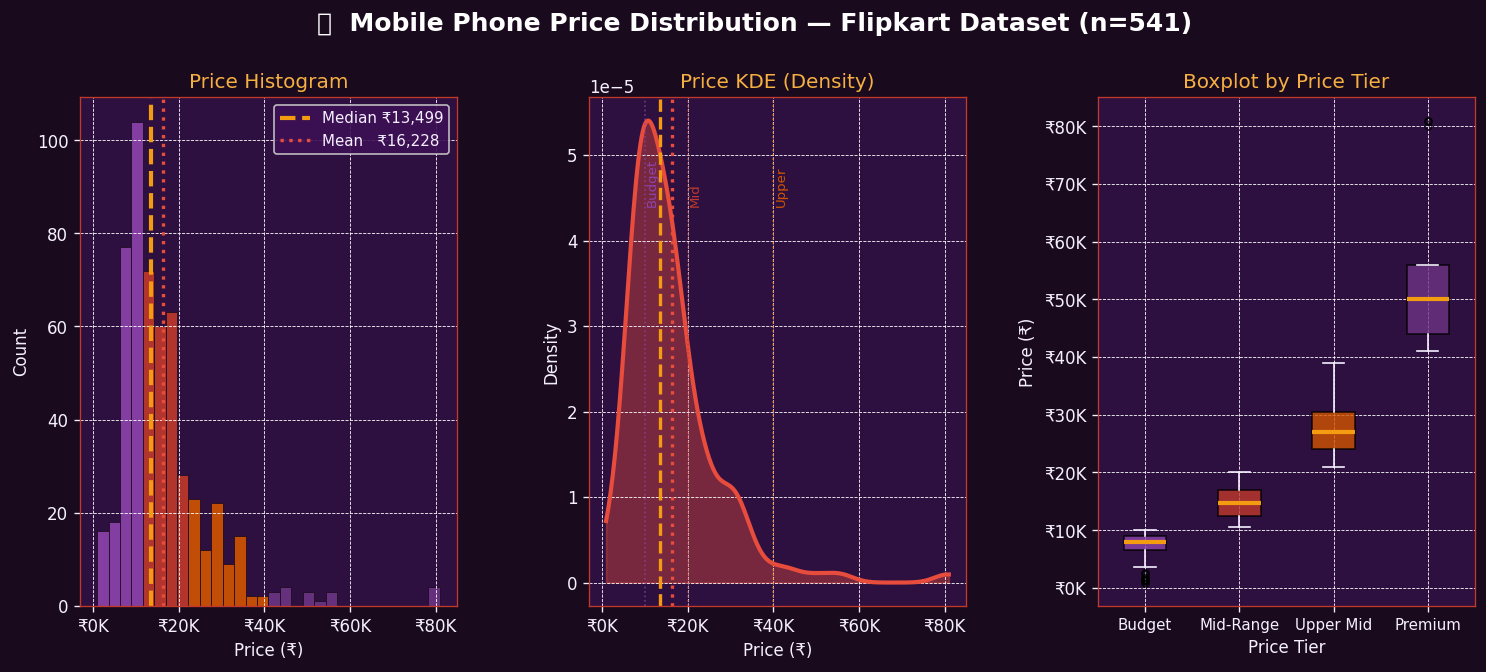

In [13]:
# VIZ 1 — Price Distribution

# Histogram · KDE · Boxplot by Price Tier

fig = plt.figure(figsize=(15, 5.5), facecolor=BG)
fig.suptitle('📊  Mobile Phone Price Distribution — Flipkart Dataset (n=541)',
             fontsize=15, fontweight='bold', color=WHITE, y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
style_ax(ax1)
n, bins, patches = ax1.hist(df['Prize'], bins=30, edgecolor=BG, linewidth=0.5, alpha=0.9)
for patch, b in zip(patches, bins[:-1]):
    if b < 10000:    patch.set_facecolor(BLUE)
    elif b < 20000:  patch.set_facecolor(ACCENT)
    elif b < 40000:  patch.set_facecolor(ORANGE)
    else:            patch.set_facecolor(PURPLE)
ax1.axvline(df['Prize'].median(), color=GOLD, linewidth=2.5, linestyle='--',
            label=f'Median ₹{df["Prize"].median():,.0f}')
ax1.axvline(df['Prize'].mean(),   color=RED,  linewidth=2,   linestyle=':',
            label=f'Mean   ₹{df["Prize"].mean():,.0f}')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax1.set_xlabel('Price (₹)'); ax1.set_ylabel('Count')
ax1.set_title('Price Histogram', fontsize=12, color=GOLD_L)
ax1.legend(fontsize=9, facecolor=SLATE, labelcolor=OFF_W, framealpha=0.9)

ax2 = fig.add_subplot(gs[1])
style_ax(ax2)
kde_x = np.linspace(df['Prize'].min(), df['Prize'].max(), 300)
kde_y = gaussian_kde(df['Prize'])(kde_x)
ax2.fill_between(kde_x, kde_y, alpha=0.4, color=ACCT_L)
ax2.plot(kde_x, kde_y, color=ACCT_L, linewidth=2.5)
ax2.axvline(df['Prize'].median(), color=GOLD, linewidth=2, linestyle='--')
ax2.axvline(df['Prize'].mean(),   color=RED,  linewidth=2, linestyle=':')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax2.set_xlabel('Price (₹)'); ax2.set_ylabel('Density')
ax2.set_title('Price KDE (Density)', fontsize=12, color=GOLD_L)
for thresh, lbl, clr in [(10000,'Budget',BLUE),(20000,'Mid',ACCENT),(40000,'Upper',ORANGE)]:
    ax2.axvline(thresh, color=clr, linewidth=1, linestyle=':', alpha=0.7)
    ax2.text(thresh+300, max(kde_y)*0.82, lbl, color=clr, fontsize=8, rotation=90)

ax3 = fig.add_subplot(gs[2])
style_ax(ax3)
tiers  = ['Budget','Mid-Range','Upper Mid','Premium']
data_t = [df[df['Price_Tier']==t]['Prize'].values for t in tiers]
bp = ax3.boxplot(data_t, labels=tiers, patch_artist=True,
                 medianprops=dict(color=GOLD, linewidth=2.5),
                 whiskerprops=dict(color=OFF_W), capprops=dict(color=OFF_W),
                 flierprops=dict(marker='o', color=GOLD_L, markersize=4, alpha=0.6))
for patch, clr in zip(bp['boxes'], [BLUE, ACCENT, ORANGE, PURPLE]):
    patch.set_facecolor(clr); patch.set_alpha(0.8)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax3.set_xlabel('Price Tier'); ax3.set_ylabel('Price (₹)')
ax3.set_title('Boxplot by Price Tier', fontsize=12, color=GOLD_L)
ax3.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()


In [14]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #00A896;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#00A896;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">📊</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 1 — Price Distribution &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Price is strongly right-skewed. Most phones cluster below ₹20K, while only a small tail extends into the ₹40K–₹80K premium range. The mean (~₹16.2K) sits above the median (~₹13.5K), confirming the effect of high-price outliers.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The market is volume-heavy in budget and mid-range products, not evenly spread across price bands. Premium devices influence averages but do not represent the typical listing.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">This is a mass-market category. Commercial success depends on winning the ₹10K–₹20K bracket, while premium devices should be handled as a niche, brand-building portfolio.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Use median-based summaries for analysis, keep premium models segmented in reporting, and position pricing strategy primarily around the mid-range battleground.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.2 — Price Tier Distribution · Bar Chart · Donut

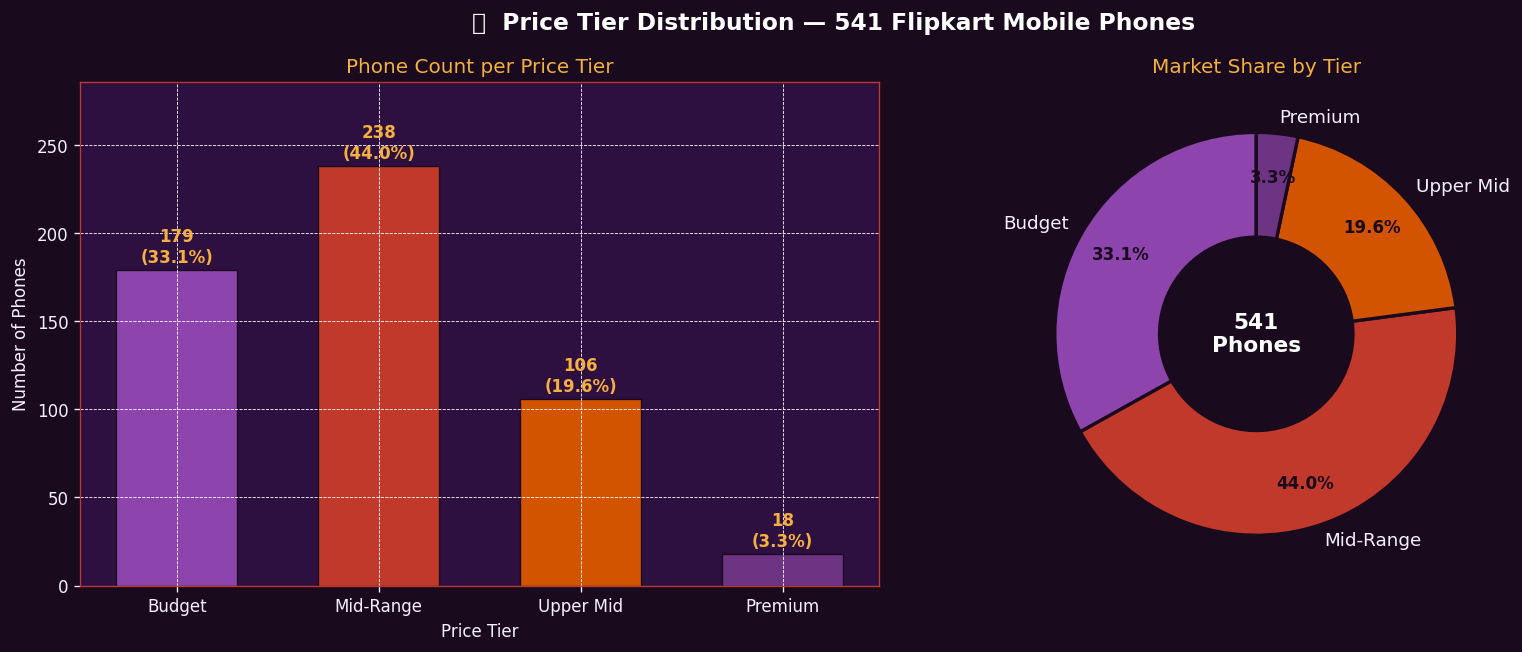

In [15]:
# VIZ 2 — Price Tier Distribution

# Bar Chart · Donut Chart · Market Segment Analysis

tier_counts = df['Price_Tier'].value_counts().reindex(['Budget','Mid-Range','Upper Mid','Premium'])
tier_clrs   = [BLUE, ACCENT, ORANGE, PURPLE]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)
fig.suptitle('💰  Price Tier Distribution — 541 Flipkart Mobile Phones',
             fontsize=14, fontweight='bold', color=WHITE)

style_ax(ax1)
bars = ax1.bar(tier_counts.index, tier_counts.values, color=tier_clrs,
               edgecolor=BG, linewidth=0.8, width=0.6)
for bar, val in zip(bars, tier_counts.values):
    pct = val / len(df) * 100
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=GOLD_L)
ax1.set_title('Phone Count per Price Tier', fontsize=12, color=GOLD_L)
ax1.set_xlabel('Price Tier'); ax1.set_ylabel('Number of Phones')
ax1.set_ylim(0, max(tier_counts)*1.2)

ax2.set_facecolor(BG)
wedges, texts, autotexts = ax2.pie(
    tier_counts.values, labels=tier_counts.index, colors=tier_clrs,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78, labeldistance=1.08,
    wedgeprops=dict(width=0.52, edgecolor=BG, linewidth=2))
for t in texts:     t.set_color(OFF_W); t.set_fontsize(11)
for at in autotexts: at.set_color(BG); at.set_fontweight('bold'); at.set_fontsize(10)
ax2.text(0, 0, f'{len(df)}\nPhones', ha='center', va='center',
         fontsize=13, fontweight='bold', color=WHITE)
ax2.set_title('Market Share by Tier', fontsize=12, color=GOLD_L)

plt.tight_layout()
plt.show()


In [16]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #F4A261;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#F4A261;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">💰</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 2 — Price Tier Distribution &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Mid-Range contributes the largest share of listings (~44%), followed by Budget (~33%). Upper Mid forms a meaningful secondary band, while Premium is a very small niche (~3%).</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The portfolio pyramid is broad at the bottom and narrow at the top. The strongest growth opportunity sits between value seekers and premium aspirants.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Mid-Range should carry the largest assortment and strongest value messaging. Premium remains important for image and credibility, but not for unit volume.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Prioritize assortment depth in Mid-Range, maintain a clear upgrade ladder into Upper Mid, and keep a focused premium lineup for halo effect rather than scale.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.3 — RAM vs Price · Scatter · Boxplot

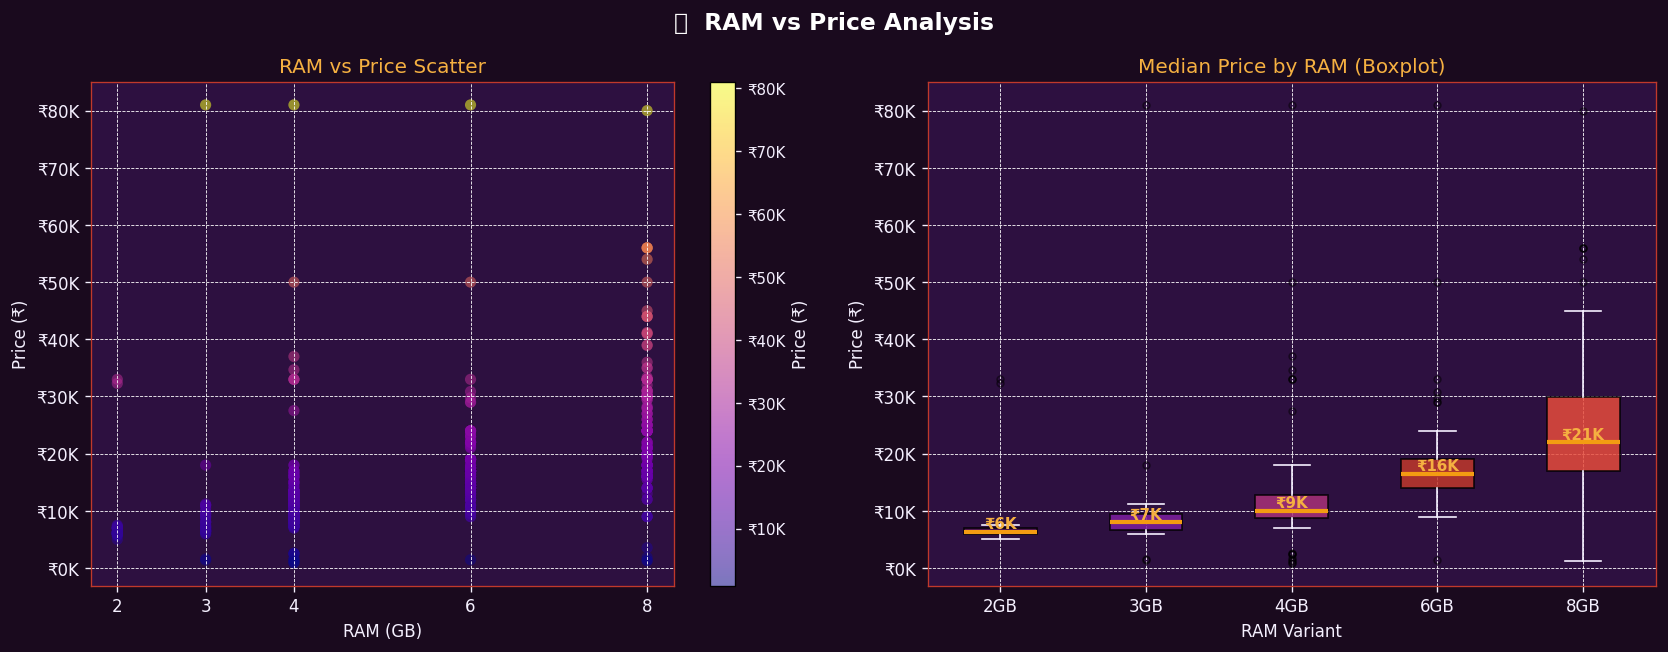

In [17]:
# VIZ 3 — RAM vs Price

ram_vals = sorted(df['RAM'].unique())
ram_data = [df[df['RAM']==r]['Prize'].values for r in ram_vals]
ram_med  = df.groupby('RAM')['Prize'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)
fig.suptitle('🧠  RAM vs Price Analysis', fontsize=14, fontweight='bold', color=WHITE)

style_ax(ax1)
sc = ax1.scatter(df['RAM'], df['Prize'], c=df['Prize'], cmap='plasma',
                 alpha=0.55, edgecolors='none', s=45)
cbar = plt.colorbar(sc, ax=ax1)
cbar.ax.tick_params(colors=OFF_W, labelsize=9)
cbar.set_label('Price (₹)', color=OFF_W, fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax1.set_xlabel('RAM (GB)'); ax1.set_ylabel('Price (₹)')
ax1.set_title('RAM vs Price Scatter', fontsize=12, color=GOLD_L)
ax1.set_xticks(ram_vals)

style_ax(ax2)
bp = ax2.boxplot(ram_data, labels=[f'{r}GB' for r in ram_vals], patch_artist=True,
                 medianprops=dict(color=GOLD, linewidth=2.5),
                 whiskerprops=dict(color=OFF_W), capprops=dict(color=OFF_W),
                 flierprops=dict(marker='o', markersize=4, color=GOLD_L, alpha=0.5))
for patch, clr in zip(bp['boxes'], RAM_COLORS[:len(ram_vals)]):
    patch.set_facecolor(clr); patch.set_alpha(0.85)
for r, val in zip(ram_vals, [ram_med[r] for r in ram_vals]):
    ax2.text(ram_vals.index(r)+1, val+600, f'₹{int(val/1000)}K',
             ha='center', fontsize=9, fontweight='bold', color=GOLD_L)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax2.set_xlabel('RAM Variant'); ax2.set_ylabel('Price (₹)')
ax2.set_title('Median Price by RAM (Boxplot)', fontsize=12, color=GOLD_L)

plt.tight_layout()
plt.show()


In [18]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #2A9D8F;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#2A9D8F;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🧠</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 3 — RAM vs Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">RAM shows a clean positive relationship with price (r ≈ 0.532). Median pricing rises sharply from low-RAM variants to 8GB models, with 4GB and 6GB acting as the high-volume transition bands.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">RAM is a strong pricing anchor, but not a standalone determinant. The spread within 4GB and 6GB indicates that camera, storage, and processor still meaningfully shape final market price.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Consumers interpret RAM as an immediate performance signal. Higher RAM configurations justify visible price stepping and work well as commercial upgrade points.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Use RAM as one of the primary pricing ladders, especially in mid-range offerings, while pairing it with storage and camera positioning to explain price gaps more convincingly.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.4 — Battery Capacity vs Price

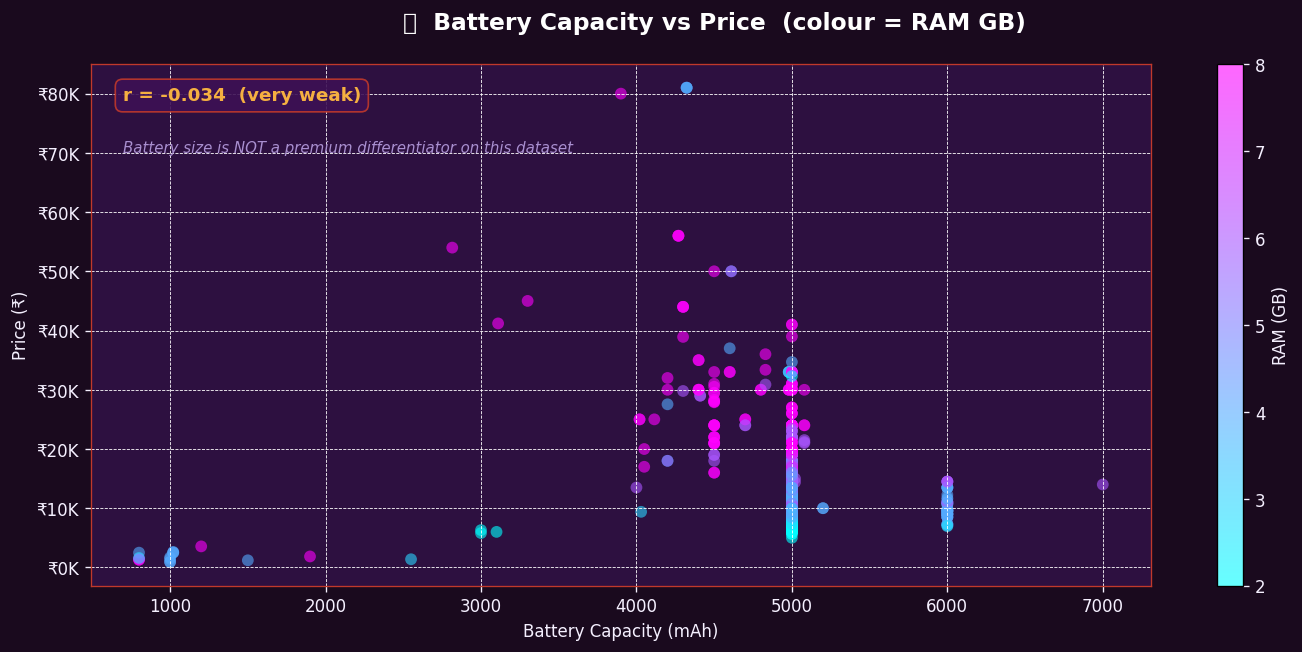

In [19]:
# VIZ 4 — Battery Capacity vs Price

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor=BG)
style_ax(ax)
fig.suptitle('🔋  Battery Capacity vs Price  (colour = RAM GB)',
             fontsize=14, fontweight='bold', color=WHITE)

sc = ax.scatter(df['Battery_'], df['Prize'],
                c=df['RAM'], cmap='cool', alpha=0.6, edgecolors='none', s=50)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('RAM (GB)', color=OFF_W, fontsize=10)
cbar.ax.tick_params(colors=OFF_W)
ax.set_xlabel('Battery Capacity (mAh)'); ax.set_ylabel('Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))

corr_bat = df[['Battery_','Prize']].corr().iloc[0,1]
ax.text(0.03, 0.93, f'r = {corr_bat:.3f}  (very weak)', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color=GOLD_L,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=SLATE, edgecolor=ACCENT, alpha=0.9))
ax.text(0.03, 0.83, 'Battery size is NOT a premium differentiator on this dataset',
        transform=ax.transAxes, fontsize=9, color=MUTED, style='italic')

plt.tight_layout()
plt.show()


In [20]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #E76F51;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#E76F51;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🔋</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 4 — Battery Capacity vs Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Battery capacity shows almost no relationship with price (r ≈ -0.034). Large batteries appear across budget, mid-range, and premium devices with heavy price overlap.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Battery has become a baseline expectation rather than a premium differentiator. Variation in price at similar battery levels is driven more by RAM, camera, and storage.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">A bigger battery alone will not support premium pricing in this market. It improves perceived practicality, but not price power.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Treat battery as a hygiene feature. Keep it competitive across all tiers, but avoid using it as the headline justification for higher prices.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.5 — Internal Storage vs Price · Bar Chart · Strip Plot

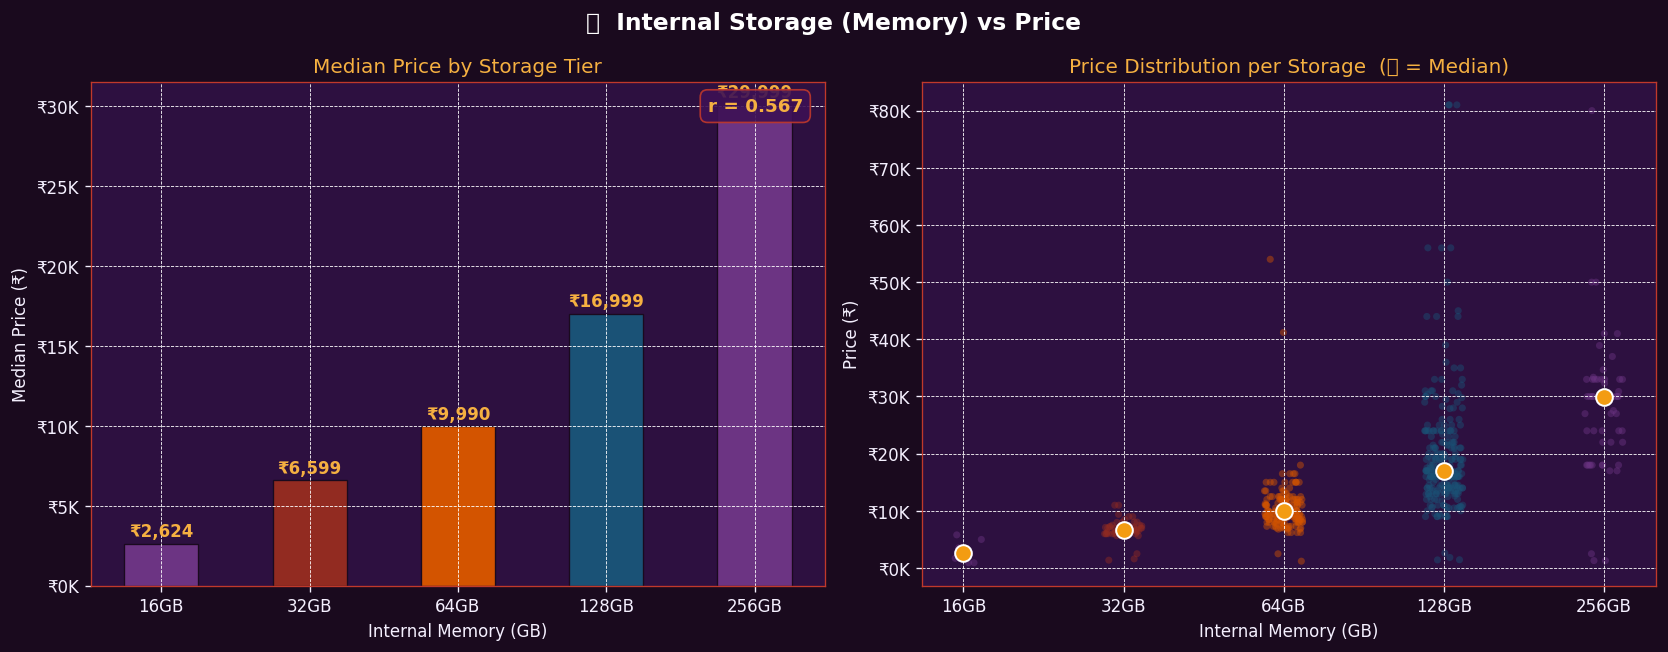

In [21]:
# VIZ 5 — Internal Storage vs Price

mem_med  = df.groupby('Memory')['Prize'].median().reset_index()
mem_vals = sorted(df['Memory'].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)
fig.suptitle('💾  Internal Storage (Memory) vs Price', fontsize=14, fontweight='bold', color=WHITE)

style_ax(ax1)
bars = ax1.bar([f'{m}GB' for m in mem_med['Memory']], mem_med['Prize'],
               color=MEM_COLORS[:len(mem_med)], edgecolor=BG, linewidth=0.8, width=0.5)
add_bar_labels(ax1, fmt='₹{:,.0f}', color=GOLD_L, fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax1.set_xlabel('Internal Memory (GB)'); ax1.set_ylabel('Median Price (₹)')
ax1.set_title('Median Price by Storage Tier', fontsize=12, color=GOLD_L)
corr_mem = df[['Memory','Prize']].corr().iloc[0,1]
ax1.text(0.97, 0.97, f'r = {corr_mem:.3f}', transform=ax1.transAxes,
         ha='right', va='top', fontsize=11, fontweight='bold', color=GOLD_L,
         bbox=dict(boxstyle='round,pad=0.4', facecolor=SLATE, edgecolor=ACCENT, alpha=0.9))

style_ax(ax2)
jitter = 0.12
for i, mem in enumerate(mem_vals):
    sub = df[df['Memory']==mem]['Prize']
    jit = np.random.uniform(-jitter, jitter, len(sub))
    ax2.scatter(np.full(len(sub), i)+jit, sub,
                color=MEM_COLORS[i%len(MEM_COLORS)], alpha=0.45, s=18, edgecolors='none')
    ax2.scatter(i, sub.median(), color=GOLD, s=100, zorder=5,
                edgecolors=WHITE, linewidths=1.2)
ax2.set_xticks(range(len(mem_vals)))
ax2.set_xticklabels([f'{m}GB' for m in mem_vals])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax2.set_xlabel('Internal Memory (GB)'); ax2.set_ylabel('Price (₹)')
ax2.set_title('Price Distribution per Storage  (⭐ = Median)', fontsize=12, color=GOLD_L)

plt.tight_layout()
plt.show()


In [22]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #8D5CF6;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#8D5CF6;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">💾</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 5 — Internal Storage vs Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Storage has the strongest correlation with price among individual features (r ≈ 0.567). Median price steps upward consistently from 32GB to 64GB, 128GB, and 256GB with relatively clean separation.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Unlike battery, storage creates a visible willingness-to-pay ladder. The 128GB tier acts as the commercial sweet spot, while 256GB strongly signals a premium configuration.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Storage is the clearest variable for pricing and variant design. Consumers appear willing to pay meaningful increments for higher memory capacity.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Make storage a central lever in variant strategy, design clear price steps between memory tiers, and highlight 128GB as the value sweet spot in sales communication.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.6 — Camera Specifications vs Price

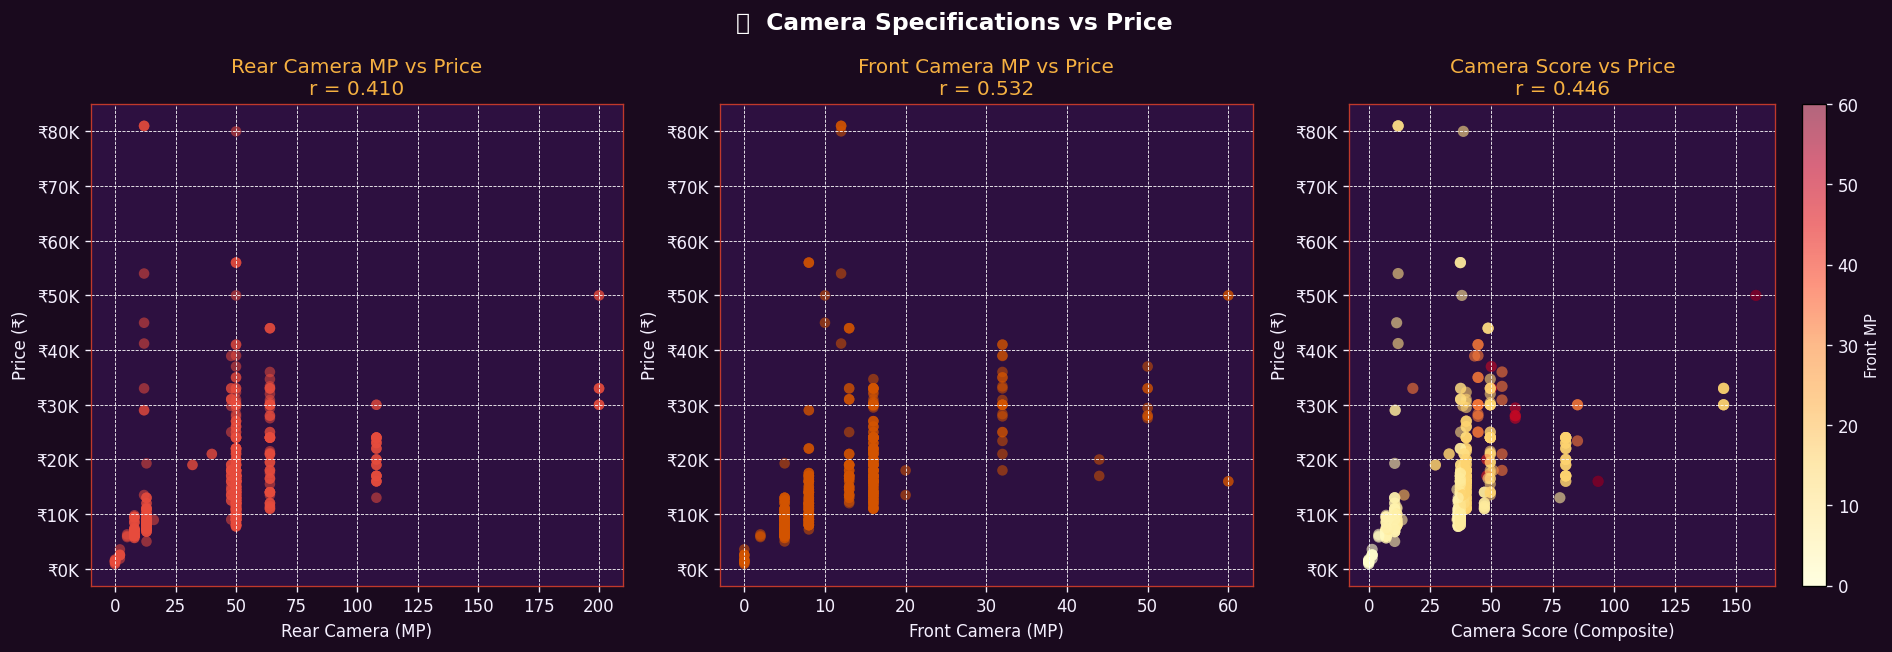

In [23]:
# VIZ 6 — Camera Specifications vs Price

# Rear · Front · Camera Score

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor=BG)
fig.suptitle('📷  Camera Specifications vs Price', fontsize=14, fontweight='bold', color=WHITE)

style_ax(axes[0])
axes[0].scatter(df['Rear_Camera_MP'], df['Prize'],
                color=ACCT_L, alpha=0.55, edgecolors='none', s=40)
r1 = df[['Rear_Camera_MP','Prize']].corr().iloc[0,1]
axes[0].set_xlabel('Rear Camera (MP)'); axes[0].set_ylabel('Price (₹)')
axes[0].set_title(f'Rear Camera MP vs Price\nr = {r1:.3f}', fontsize=12, color=GOLD_L)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))

style_ax(axes[1])
axes[1].scatter(df['Front_Camera_MP'], df['Prize'],
                color=ORANGE, alpha=0.55, edgecolors='none', s=40)
r2 = df[['Front_Camera_MP','Prize']].corr().iloc[0,1]
axes[1].set_xlabel('Front Camera (MP)'); axes[1].set_ylabel('Price (₹)')
axes[1].set_title(f'Front Camera MP vs Price\nr = {r2:.3f}', fontsize=12, color=GOLD_L)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))

style_ax(axes[2])
sc = axes[2].scatter(df['Camera_Score'], df['Prize'],
                     c=df['Front_Camera_MP'], cmap='YlOrRd',
                     alpha=0.6, edgecolors='none', s=45)
cbar = plt.colorbar(sc, ax=axes[2])
cbar.set_label('Front MP', color=OFF_W, fontsize=9)
cbar.ax.tick_params(colors=OFF_W)
r3 = df[['Camera_Score','Prize']].corr().iloc[0,1]
axes[2].set_xlabel('Camera Score (Composite)'); axes[2].set_ylabel('Price (₹)')
axes[2].set_title(f'Camera Score vs Price\nr = {r3:.3f}', fontsize=12, color=GOLD_L)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))

plt.tight_layout()
plt.show()


In [24]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #3D5A80;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#3D5A80;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">📷</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 6 — Camera Specifications vs Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Camera variables show meaningful positive relationships with price. Front Camera MP (r ≈ 0.532) is stronger than Rear Camera MP (r ≈ 0.410), while the engineered Camera Score (r ≈ 0.446) provides a balanced composite signal.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The data suggests that selfie-oriented specifications have real market value. The composite score validates feature engineering by smoothing multiple camera signals into one usable predictor.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Camera positioning matters commercially, and front camera quality is especially influential for perceived value in this dataset.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Retain front camera, rear camera, and camera score in the ML-ready feature set. In product messaging, elevate selfie camera specifications alongside overall camera quality.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.7 — AI Lens & Mobile Height vs Price

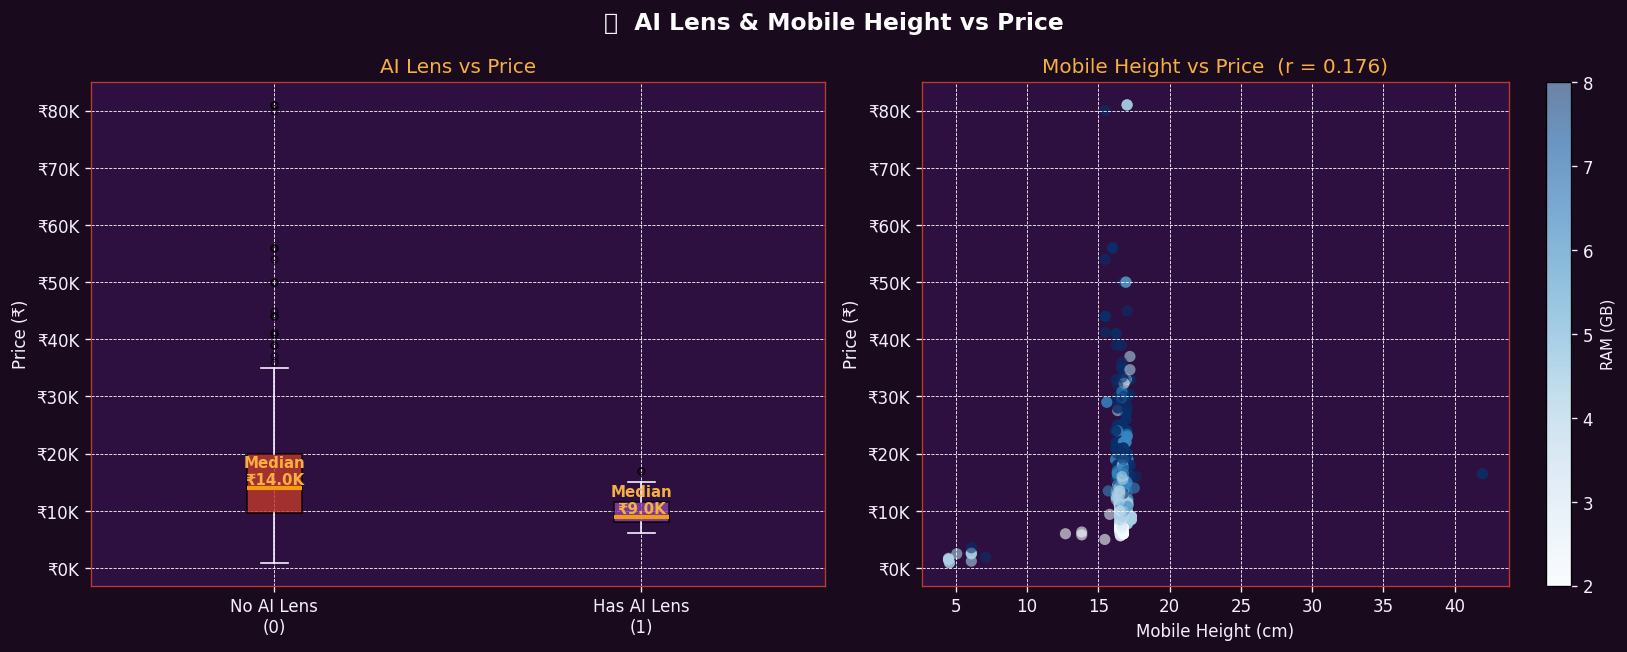

In [25]:
# VIZ 7 — AI Lens & Mobile Height vs Price

# Boxplot · Scatter  —  Secondary Feature Analysis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)
fig.suptitle('🔬  AI Lens & Mobile Height vs Price', fontsize=14, fontweight='bold', color=WHITE)

style_ax(ax1)
ai_groups = [df[df['AI Lens']==0]['Prize'], df[df['AI Lens']==1]['Prize']]
bp = ax1.boxplot(ai_groups, labels=['No AI Lens\n(0)','Has AI Lens\n(1)'], patch_artist=True,
                 medianprops=dict(color=GOLD, linewidth=2.5),
                 whiskerprops=dict(color=OFF_W), capprops=dict(color=OFF_W),
                 flierprops=dict(marker='o', markersize=4, color=GOLD_L, alpha=0.5))
for patch, clr in zip(bp['boxes'], [ACCENT, BLUE]):
    patch.set_facecolor(clr); patch.set_alpha(0.8)
for i, grp in enumerate(ai_groups):
    ax1.text(i+1, grp.median()+600, f'Median\n₹{grp.median()/1000:.1f}K',
             ha='center', fontsize=9, color=GOLD_L, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax1.set_ylabel('Price (₹)'); ax1.set_title('AI Lens vs Price', fontsize=12, color=GOLD_L)

style_ax(ax2)
sc = ax2.scatter(df['Mobile Height'], df['Prize'],
                 c=df['RAM'], cmap='Blues', alpha=0.6, edgecolors='none', s=45)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('RAM (GB)', color=OFF_W, fontsize=9)
cbar.ax.tick_params(colors=OFF_W)
r_h = df[['Mobile Height','Prize']].corr().iloc[0,1]
ax2.set_xlabel('Mobile Height (cm)'); ax2.set_ylabel('Price (₹)')
ax2.set_title(f'Mobile Height vs Price  (r = {r_h:.3f})', fontsize=12, color=GOLD_L)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))

plt.tight_layout()
plt.show()


In [26]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #457B9D;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#457B9D;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🔬</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 7 — AI Lens & Mobile Height vs Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">AI Lens has a weak inverse relationship with price (r ≈ -0.154), while Mobile Height shows only a weak positive signal (r ≈ 0.176). Devices marked with AI Lens tend to cluster in lower-priced bands.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The AI Lens label behaves more like a budget-marketing tag than a true premium feature. Mobile size adds only secondary explanatory power.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Not every visible feature contributes pricing power. Some attributes mainly support merchandising language rather than actual market premium.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Use AI Lens cautiously in modelling and positioning. Keep Mobile Height as an auxiliary feature, but do not depend on either variable as a lead pricing signal.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.8 — Full Correlation Heatmap

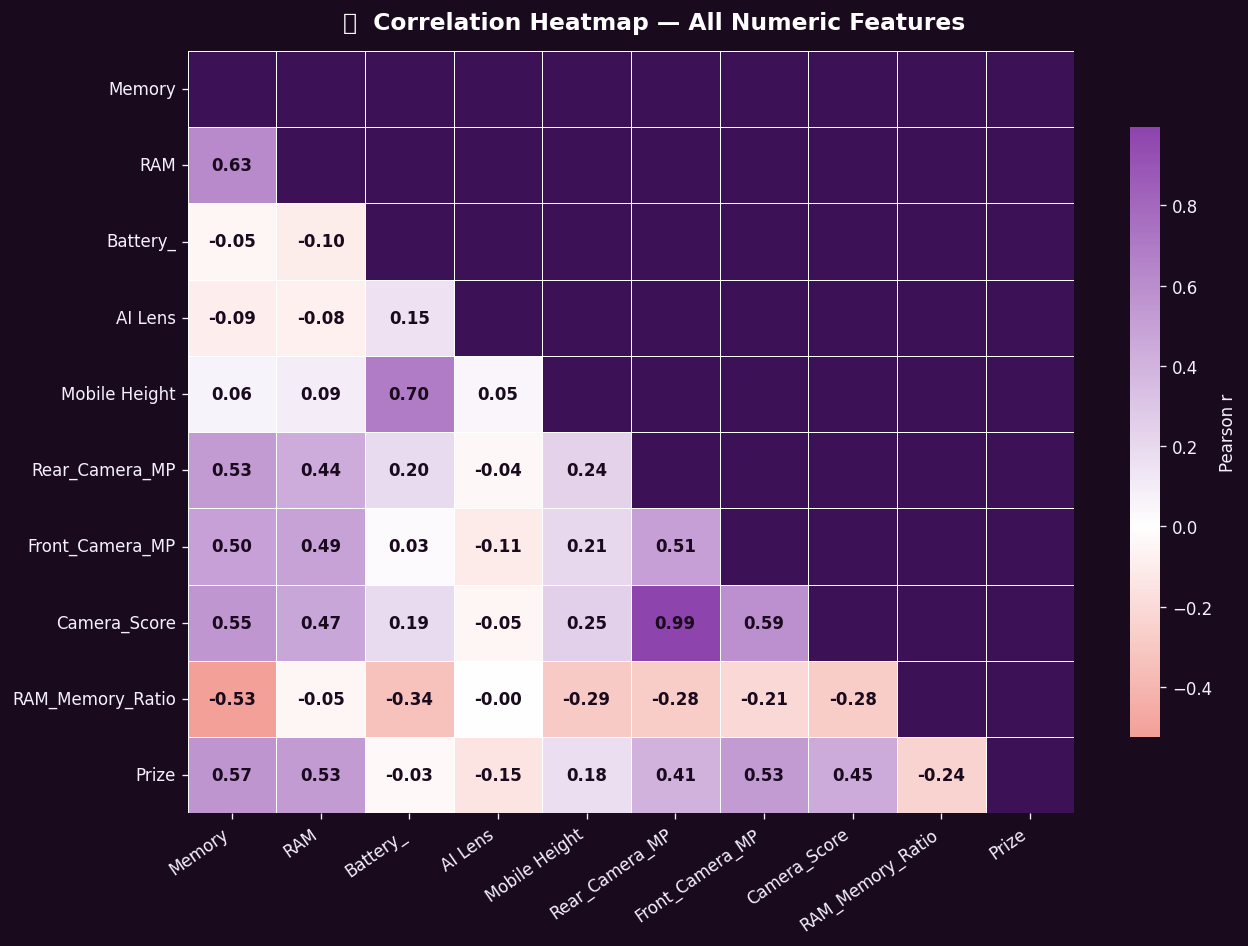

In [27]:
# VIZ 8 — Full Correlation Heatmap

from matplotlib.colors import LinearSegmentedColormap

cmap_hm = LinearSegmentedColormap.from_list('crimson_purple',
    ['#E74C3C','#FFFFFF','#8E44AD'], N=256)

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
fig.suptitle('🔗  Correlation Heatmap — All Numeric Features',
             fontsize=14, fontweight='bold', color=WHITE)
ax.set_facecolor(SLATE)

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap=cmap_hm, center=0, linewidths=0.6,
            annot_kws={'size':10, 'color':BG, 'weight':'bold'},
            ax=ax, cbar_kws={'shrink':0.8})

ax.tick_params(colors=OFF_W, labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', color=OFF_W)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=OFF_W)
ax.collections[0].colorbar.ax.tick_params(colors=OFF_W)
ax.collections[0].colorbar.set_label('Pearson r', color=OFF_W)

plt.tight_layout()
plt.show()


In [28]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #06D6A0;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#06D6A0;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🔗</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 8 — Full Correlation Heatmap &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The heatmap shows a strong positive cluster among Memory, RAM, Front Camera MP, Rear Camera MP, and Camera Score, while Battery remains near-neutral and AI Lens trends negative.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The main pricing ecosystem is built around performance, storage, and camera capability. Some multicollinearity exists, particularly between RAM and Memory.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The category has a coherent premium stack: better phones tend to improve multiple flagship features together rather than one feature in isolation.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Use the heatmap to guide feature selection: keep strong variables, monitor multicollinearity in linear models, and prefer tree-based models when interaction effects matter.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.9 — Feature Importance · Horizontal |r| Bar Chart

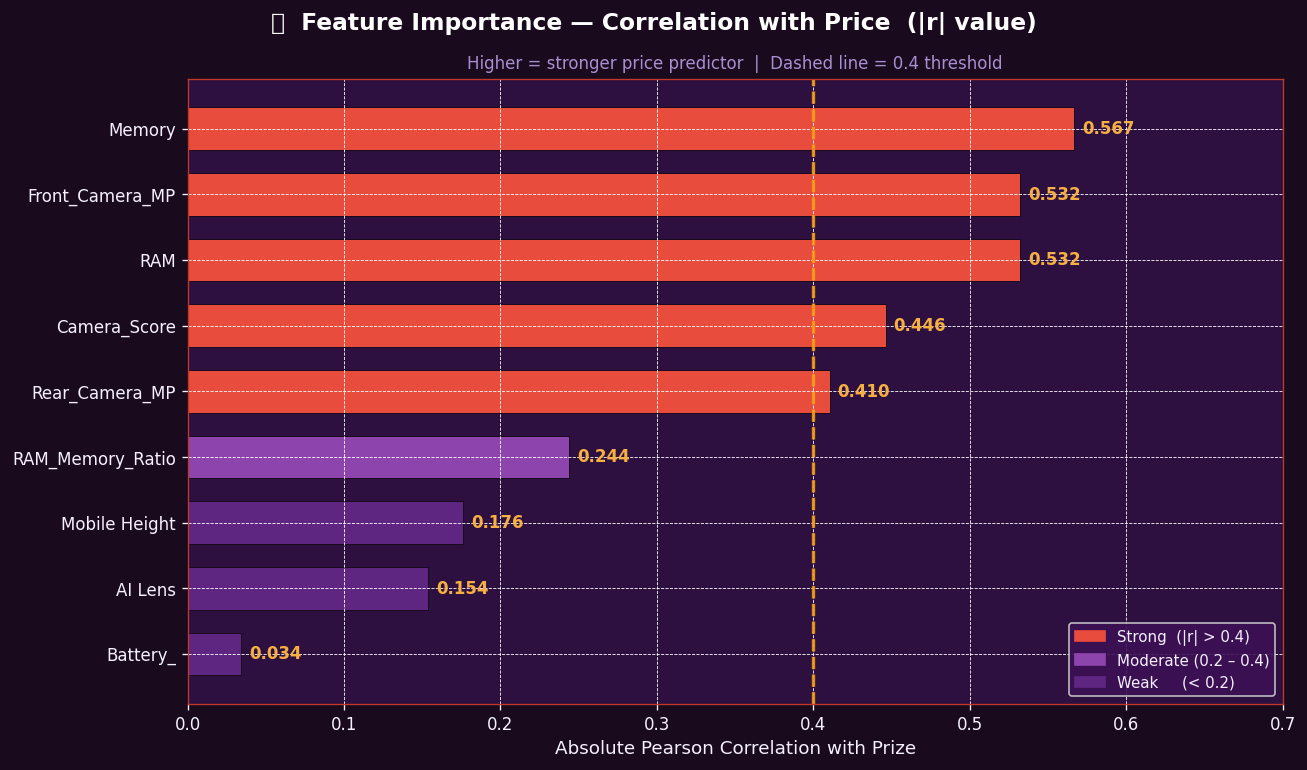

In [29]:
# VIZ 9 — Feature Importance

feat_corr = corr_mat['Prize'].drop('Prize').abs().sort_values(ascending=True)

colors_bar = []
for v in feat_corr.values:
    if v > 0.4:    colors_bar.append(RED)
    elif v > 0.2:  colors_bar.append(BLUE)
    else:          colors_bar.append(SLATE_L)

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=BG)
style_ax(ax, gc="#FFFFFF15")
fig.suptitle('🏆  Feature Importance — Correlation with Price  (|r| value)',
             fontsize=14, fontweight='bold', color=WHITE)

ax.barh(feat_corr.index, feat_corr.values, color=colors_bar,
        edgecolor=BG, linewidth=0.6, height=0.65)
add_hbar_labels(ax, color=GOLD_L, fontsize=10)
ax.axvline(0.4, color=GOLD, linewidth=2, linestyle='--', alpha=0.9)
ax.set_xlim(0, 0.70)
ax.set_xlabel('Absolute Pearson Correlation with Prize', fontsize=11)
ax.set_title('Higher = stronger price predictor  |  Dashed line = 0.4 threshold',
             fontsize=10, color=MUTED)

patches = [
    mpatches.Patch(color=RED,     label='Strong  (|r| > 0.4)'),
    mpatches.Patch(color=BLUE,    label='Moderate (0.2 – 0.4)'),
    mpatches.Patch(color=SLATE_L, label='Weak     (< 0.2)'),
]
ax.legend(handles=patches, fontsize=9, facecolor=SLATE, labelcolor=OFF_W,
          framealpha=0.9, loc='lower right')

plt.tight_layout()
plt.show()


In [30]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #FFB703;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#FFB703;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🏆</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 9 — Feature Importance Ranking &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Memory ranks first, followed by Front Camera MP and RAM, with Camera Score and Rear Camera MP also crossing strong relevance levels. Battery, AI Lens, and RAM-Memory Ratio remain weak.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">A compact high-signal feature set explains most pricing variation. Feature engineering added value — Camera Score enters the top tier of useful predictors.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The pricing story is concentrated, not diffuse. A few variables do most of the commercial work, which simplifies downstream modelling.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Build the first regression models around the top six predictors, de-emphasize weak variables, and compare model performance with and without the engineered composite features.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.10 — Top 10 Processors by Average Price

In [ ]:
# VIZ 10 — Top 10 Processors by Average Price

proc_price = df_enc.groupby('Processor_')['Prize'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax, gc="#FFFFFF15")
fig.suptitle('⚙️  Top 10 Processors by Average Phone Price',
             fontsize=14, fontweight='bold', color=WHITE)

grad_colors = [plt.cm.RdPu(0.4 + i*0.06) for i in range(10)]
bars = ax.barh(proc_price.index[::-1], proc_price.values[::-1],
               color=grad_colors, edgecolor=BG, linewidth=0.6, height=0.65)
for bar, val in zip(bars, proc_price.values[::-1]):
    ax.text(val+200, bar.get_y()+bar.get_height()/2,
            f'₹{int(val/1000)}K', va='center', fontsize=9,
            fontweight='bold', color=GOLD_L)
ax.set_xlabel('Average Price (₹)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{int(x/1000)}K'))
ax.set_title('Premium processors command significantly higher average prices',
             fontsize=10, color=MUTED)

plt.tight_layout()
plt.show()


In [31]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #7B2CBF;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#7B2CBF;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">⚙️</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 10 — Top 10 Processors by Average Price &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Premium processors such as Apple Bionic and higher-end Snapdragon variants occupy the highest average price bands, while entry-level chipsets map to lower-price segments.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Processor is functioning as a tier signal. The chipset family reflects the broader positioning of the device and aligns well with consumer expectations of performance class.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Processor branding supports price credibility. Premium-tier chipsets help justify higher prices, while lower-end processors naturally align with value-first products.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Retain processor in the modelling pipeline. From a portfolio angle, align chipset selection carefully with intended price tier.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.11 — RAM × Storage · Median Price Heatmap

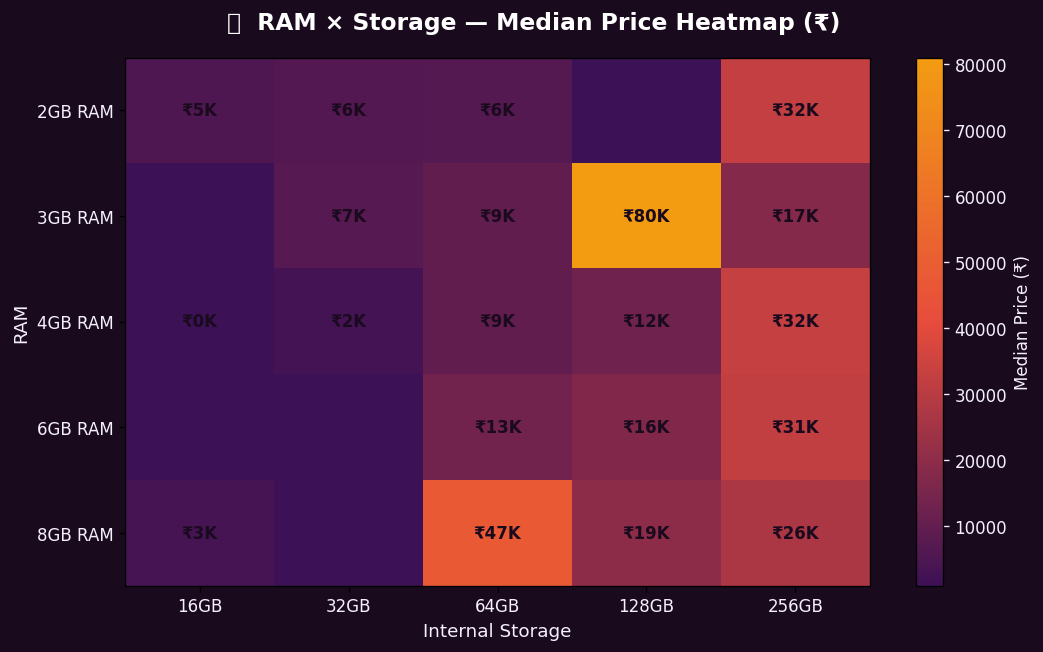

In [32]:
# VIZ 11 — RAM × Storage Heatmap

pivot  = df_enc.pivot_table(values='Prize', index='RAM', columns='Memory', aggfunc='median')
cmap2  = LinearSegmentedColormap.from_list('amber_crimson', [SLATE, ACCT_L, GOLD], N=256)

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BG)
ax.set_facecolor(SLATE)
fig.suptitle('🗺️  RAM × Storage — Median Price Heatmap (₹)',
             fontsize=14, fontweight='bold', color=WHITE)

im   = ax.imshow(pivot.values, cmap=cmap2, aspect='auto')
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(colors=OFF_W)
cbar.set_label('Median Price (₹)', color=OFF_W)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'₹{int(val/1000)}K', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=BG)

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{c}GB' for c in pivot.columns], color=OFF_W, fontsize=10)
ax.set_yticklabels([f'{r}GB RAM' for r in pivot.index], color=OFF_W, fontsize=10)
ax.set_xlabel('Internal Storage', fontsize=11, color=OFF_W)
ax.set_ylabel('RAM', fontsize=11, color=OFF_W)

plt.tight_layout()
plt.show()


In [33]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #118AB2;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#118AB2;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">🗺️</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 11 — RAM × Storage Heatmap &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">High-RAM and high-storage combinations command the highest median prices, while low-RAM and low-storage combinations define the entry floor. The 4GB + 128GB zone appears especially strong in the mid-market.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">RAM and Memory do not act independently; their interaction matters. Premium pricing emerges most clearly when both specs scale together.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Variant architecture matters as much as individual specification choices. Consumers reward balanced high-performance combinations more than isolated single-feature upgrades.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Consider interaction features such as RAM × Memory for modelling, and design variant ladders around coherent configuration bundles rather than isolated spec jumps.</div>
      </div>
    </div>
  </div>
</div>
"""))


### 7.12 — Feature Engineering Summary Dashboard

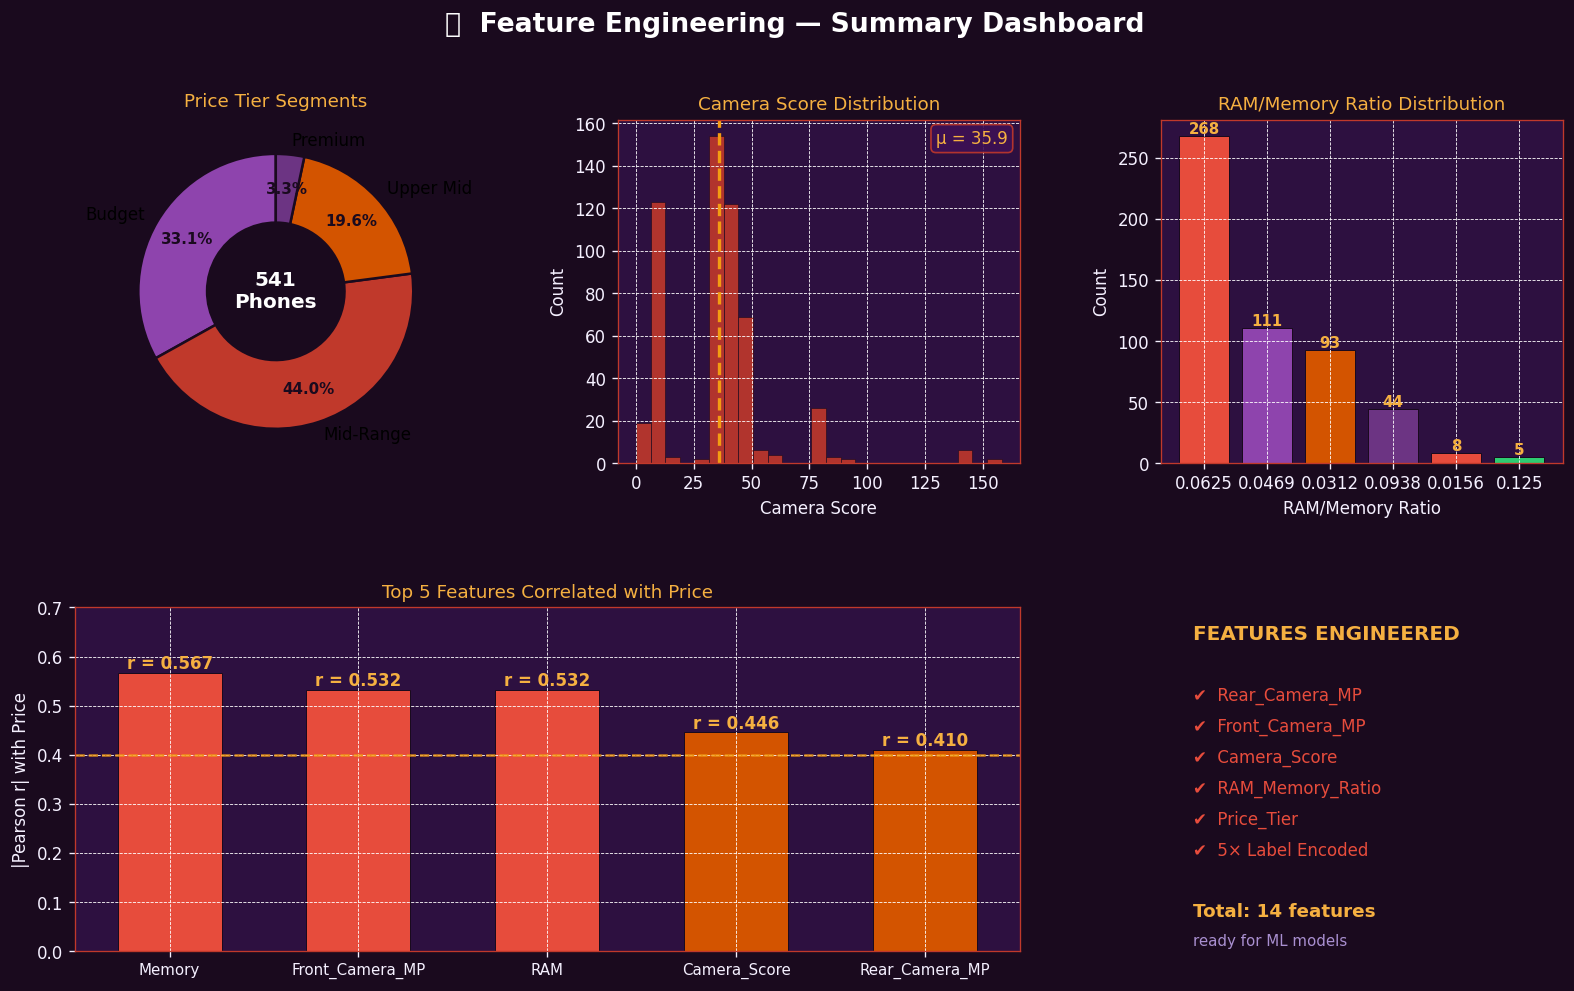

In [34]:
# VIZ 12 — Feature Engineering Summary Dashboard

fig = plt.figure(figsize=(16, 9), facecolor=BG)
fig.suptitle('📐  Feature Engineering — Summary Dashboard',
             fontsize=16, fontweight='bold', color=WHITE, y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor(BG)
tc_data = df['Price_Tier'].value_counts().reindex(['Budget','Mid-Range','Upper Mid','Premium'])
wedges, _, autotexts = ax1.pie(tc_data.values, labels=tc_data.index,
    colors=[BLUE,ACCENT,ORANGE,PURPLE], autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=1.5))
for at in autotexts: at.set_color(BG); at.set_fontweight('bold'); at.set_fontsize(9)
ax1.text(0,0,f'{len(df)}\nPhones',ha='center',va='center',fontsize=12,fontweight='bold',color=WHITE)
ax1.set_title('Price Tier Segments', fontsize=11, color=GOLD_L, pad=8)

ax2 = fig.add_subplot(gs[0,1]); style_ax(ax2)
ax2.hist(df['Camera_Score'], bins=25, color=ACCENT, edgecolor=BG, linewidth=0.4, alpha=0.9)
ax2.axvline(df['Camera_Score'].mean(), color=GOLD, linewidth=2, linestyle='--')
ax2.set_xlabel('Camera Score', fontsize=10); ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('Camera Score Distribution', fontsize=11, color=GOLD_L)
ax2.text(0.97,0.93,f'μ = {df["Camera_Score"].mean():.1f}',transform=ax2.transAxes,
         ha='right', fontsize=10, color=GOLD_L,
         bbox=dict(boxstyle='round',facecolor=SLATE,edgecolor=ACCENT,alpha=0.9))

ax3 = fig.add_subplot(gs[0,2]); style_ax(ax3)
ratio_counts = df['RAM_Memory_Ratio'].value_counts().head(6)
ax3.bar(ratio_counts.index.astype(str), ratio_counts.values,
        color=[ACCT_L,BLUE,ORANGE,PURPLE,RED,GREEN][:len(ratio_counts)],
        edgecolor=BG, linewidth=0.6)
for i,(idx,val) in enumerate(zip(ratio_counts.index,ratio_counts.values)):
    ax3.text(i,val+2,str(val),ha='center',fontsize=9,fontweight='bold',color=GOLD_L)
ax3.set_xlabel('RAM/Memory Ratio',fontsize=10); ax3.set_ylabel('Count',fontsize=10)
ax3.set_title('RAM/Memory Ratio Distribution',fontsize=11,color=GOLD_L)

ax4 = fig.add_subplot(gs[1,0:2]); style_ax(ax4)
feat_corr = corr_mat['Prize'].drop('Prize').abs().sort_values(ascending=False).head(5)
bars = ax4.bar(feat_corr.index, feat_corr.values, color=[RED,RED,RED,ORANGE,ORANGE],
               edgecolor=BG, linewidth=0.6, width=0.55)
for bar,val in zip(bars,feat_corr.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
             f'r = {val:.3f}', ha='center', fontsize=10, fontweight='bold', color=GOLD_L)
ax4.axhline(0.4, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8)
ax4.set_ylim(0,0.70); ax4.set_ylabel('|Pearson r| with Price',fontsize=10)
ax4.set_title('Top 5 Features Correlated with Price',fontsize=11,color=GOLD_L)
ax4.tick_params(axis='x',labelsize=9)

ax5 = fig.add_subplot(gs[1,2]); ax5.set_facecolor(SLATE_L); ax5.axis('off')
lines = [("FEATURES ENGINEERED",GOLD_L,12,True),("",WHITE,9,False),
         ("✔  Rear_Camera_MP",ACCT_L,10,False),("✔  Front_Camera_MP",ACCT_L,10,False),
         ("✔  Camera_Score",ACCT_L,10,False),("✔  RAM_Memory_Ratio",ACCT_L,10,False),
         ("✔  Price_Tier",ACCT_L,10,False),("✔  5× Label Encoded",ACCT_L,10,False),
         ("",WHITE,9,False),("Total: 14 features",GOLD_L,11,True),
         ("ready for ML models",MUTED,9,False)]
y = 0.95
for line,clr,sz,bold in lines:
    ax5.text(0.08,y,line,transform=ax5.transAxes,color=clr,fontsize=sz,
             fontweight='bold' if bold else 'normal',va='top')
    y -= 0.09

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [35]:
from IPython.display import HTML, display
display(HTML("""
<div style="margin:14px 0 20px 0;border-radius:14px;overflow:hidden;font-family:Segoe UI,Arial,sans-serif;background:#0E1726;border:1.6px solid #EF476F;box-shadow:0 8px 20px rgba(0,0,0,0.28);">
  <div style="background:#EF476F;padding:12px 18px;display:flex;align-items:center;gap:10px;">
    <span style="font-size:22px;">📐</span>
    <span style="color:#FFF;font-weight:700;font-size:15px;">VIZ 12 — Feature Engineering Summary Dashboard &middot; Interpretation</span>
  </div>
  <div style="padding:14px 18px 16px;">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;">
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">📊 Key Observation</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">The dashboard consolidates the market mix, engineered camera feature, RAM-to-storage patterns, top correlations, and ML-ready dimensionality. The engineered dataset is clean, structured, and analysis-ready.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">🔍 Analytical Insight</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Feature engineering materially improved the analytical value of the dataset. Extracted and derived variables convert descriptive product text into modelling-ready predictors.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">💼 Business Meaning</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">This project is no longer just a descriptive EDA exercise; it has produced a usable feature layer that supports practical price prediction work.</div>
      </div>
      <div style="background:#132238;border:1px solid #27476E;border-radius:10px;padding:12px 14px;">
        <div style="color:#FFD54F;font-weight:700;font-size:12px;margin-bottom:6px;">⚙️ Recommended Action</div>
        <div style="color:#F3F6FA;font-size:12.5px;line-height:1.6;">Move into the modelling phase with the selected high-signal variables, benchmark a Random Forest baseline first, and use this engineered dataset as the final training-ready input.</div>
      </div>
    </div>
  </div>
</div>
"""))


## 📝 Step 8 — Project Summary & Business Recommendations

In [36]:
# Step 8 — Project Summary & Business Recommendations

feat_corr_top = corr_mat['Prize'].drop('Prize').abs().sort_values(ascending=False).head(5)

print('=' * 68)
print('    NHIS PROJECT 4 — EDA & FEATURE ENGINEERING SUMMARY')
print('    Author: Neha Chhapariya')
print('=' * 68)
print(f'''
📊  DATASET OVERVIEW
  ┌─────────────────────────────────────────────────────┐
  │  Total Records     : {df.shape[0]}                         │
  │  Original Features : {df.shape[1]} →  Engineered: {df_final.shape[1]}          │
  │  Price Range       : ₹{df_enc["Prize"].min():,} — ₹{df_enc["Prize"].max():,}     │
  │  Median Price      : ₹{df_enc["Prize"].median():,.0f}                     │
  │  Missing Values    : NONE  ✅                          │
  │  Duplicate Rows    : {df.duplicated().sum()}                            │
  └─────────────────────────────────────────────────────┘
''')

print('⚙️   FEATURES ENGINEERED')
feats_eng = [
    ('Rear_Camera_MP',   'Numeric MP regex-extracted from "Rear Camera" string'),
    ('Front_Camera_MP',  'Numeric MP regex-extracted from "Front Camera" string'),
    ('Camera_Score',     'Composite: (Rear × 0.7) + (Front × 0.3)'),
    ('RAM_Memory_Ratio', 'RAM ÷ Internal Storage (performance-per-GB index)'),
    ('Price_Tier',       'Budget / Mid-Range / Upper Mid / Premium segments'),
    ('Label Encoding',   'Applied to: Model, Colour, Processor, Rear/Front Camera'),
]
for i,(feat,desc) in enumerate(feats_eng,1):
    print(f'  {i}. {feat:<22} — {desc}')

print()
print('🔗  TOP CORRELATED FEATURES WITH PRIZE')
print()
print('  Feature              │  r value │  Bar               │  Strength')
print('  ─────────────────────┼──────────┼────────────────────┼───────────')
for feat, val in feat_corr_top.items():
    bar = '█' * int(val * 20)
    tag = '★★★ Strong' if val > 0.4 else '★★  Moderate'
    print(f'  {feat:<22} │  {val:+.4f} │ {bar:<20} │  {tag}')

print('''
💡  BUSINESS RECOMMENDATIONS
  ┌─────────────────────────────────────────────────────────────────────┐
  │  1. Memory (Storage) is the #1 price driver  (r=0.567)             │
  │     → Use as the primary pricing and portfolio design criterion.   │
  │  2. Front Camera MP is equally decisive  (r=0.532)                 │
  │     → Lead selfie specs in marketing for mid-to-upper segments.   │
  │  3. RAM is tied with Front Camera  (r=0.532)                       │
  │     → 8GB RAM commands ≈3.5× the median price of 2GB variants.   │
  │  4. Camera Score composite useful for product benchmarking          │
  │  5. Battery capacity shows near-zero correlation  (r=−0.034)       │
  │     → Not a premium differentiator; spread evenly across tiers.   │
  │  6. AI Lens inversely correlated  (r=−0.154)                       │
  │     → Present mostly in budget phones; not a premium marker yet.  │
  └─────────────────────────────────────────────────────────────────────┘

🔜  NEXT STEPS  (Upcoming ML Session)
  ├── Build Models  : Linear Regression · Decision Tree · Random Forest
  ├── Evaluate      : MAE · RMSE · R² Score
  └── Validate      : Feature importances from tree models vs correlation
''')
print('=' * 68)
print('✅  End of NHIS Project 4 — Neha Chhapariya')


    NHIS PROJECT 4 — EDA & FEATURE ENGINEERING SUMMARY
    Author: Neha Chhapariya

📊  DATASET OVERVIEW
  ┌─────────────────────────────────────────────────────┐
  │  Total Records     : 541                         │
  │  Original Features : 16 →  Engineered: 14          │
  │  Price Range       : ₹920 — ₹80,999     │
  │  Median Price      : ₹13,499                     │
  │  Missing Values    : NONE  ✅                          │
  │  Duplicate Rows    : 10                            │
  └─────────────────────────────────────────────────────┘

⚙️   FEATURES ENGINEERED
  1. Rear_Camera_MP         — Numeric MP regex-extracted from "Rear Camera" string
  2. Front_Camera_MP        — Numeric MP regex-extracted from "Front Camera" string
  3. Camera_Score           — Composite: (Rear × 0.7) + (Front × 0.3)
  4. RAM_Memory_Ratio       — RAM ÷ Internal Storage (performance-per-GB index)
  5. Price_Tier             — Budget / Mid-Range / Upper Mid / Premium segments
  6. Label Encoding        

---
### ✅ End of NHIS Project 4

| Field | Detail |
|---|---|
| **Author** | Neha Chhapariya |
| **Institution** | DigiCrome |
| **Programme** | NHIS Internship Programme |
| **Theme** | Deep Purple · Crimson · Amber |
| **Status** | ✅ EDA Complete — Ready for ML Phase |
